## Imports

In [29]:
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import visualkeras

from keras.callbacks import EarlyStopping

from keras.utils import to_categorical

## Functions

In [31]:
print("Dispositivos fisicos disponibles: ", tf.config.list_physical_devices())

Dispositivos fisicos disponibles:  [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [ ]:
def show_image(image):

    plt.imshow(image)
    plt.axis("off")
    plt.show()

## Preprocessing

#### LOADING DATA

In [3]:
(x_train_mock, y_train_mock), (x_test_mock, y_test_mock) = keras.datasets.cifar100.load_data()
assert x_train_mock.shape == (50000, 32, 32, 3)
assert x_test_mock.shape == (10000, 32, 32, 3)
assert y_train_mock.shape == (50000, 1)
assert y_test_mock.shape == (10000, 1)

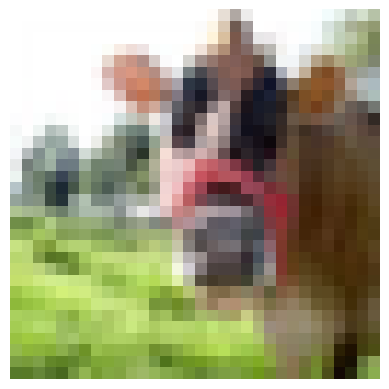

In [4]:
show_image(x_train_mock[0])

In [5]:
X_train = []
y_train = []
X_test = []
y_test = []

In [6]:
y_train_mock = y_train_mock.flatten()
y_test_mock = y_test_mock.flatten()

In [7]:
for i in range(len(x_train_mock)):
    if y_train_mock[i] < 20:
        X_train.append(x_train_mock[i])
        y_train.append(y_train_mock[i])

for i in range(len(x_test_mock)):
    if y_test_mock[i] < 20:
        X_test.append(x_test_mock[i])
        y_test.append(y_test_mock[i])

In [8]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

In [9]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [10]:
len(X_train), len(y_train), len(X_test), len(y_test)

(10000, 10000, 2000, 2000)

## Models

### Model 1

#### Creation

**Define Model**

In [11]:
data_augmentation_layer = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.1),
        keras.layers.RandomZoom(0.2),
    ]
)

In [12]:
inputs = keras.Input(shape=(32, 32, 3, ))

x = data_augmentation_layer(inputs)

x = keras.layers.Rescaling(1./255)(x)
x = keras.layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.4)(x)

outputs = keras.layers.Dense(20, activation="softmax")(x)
model_1 = keras.Model(inputs = inputs, outputs = outputs)
model_1.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │       216,340 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,732 (920.83 KB)

 Trainable params: 235,732 (920.83 KB)

 Non-trainable params: 0 (0.00 B)

d:\Clase\DL\Práctica\env\.venv\Lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


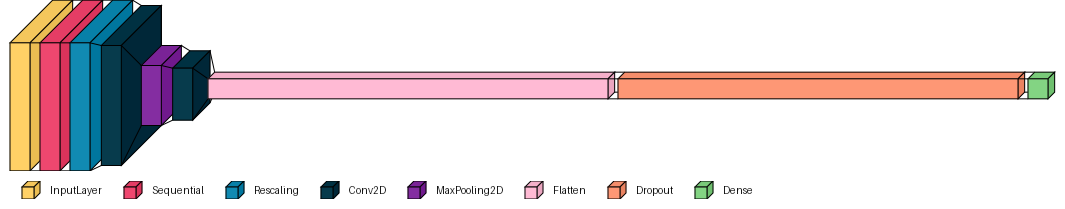

In [30]:
visualkeras.layered_view(model_1, legend=True)

**Compile Model**

In [13]:
model_1.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics = ["accuracy"]
)

#### Tranining

In [ ]:
early_stopping_cb = EarlyStopping(patience=15, monitor="val_loss", mode="min", restore_best_weights=True)

In [15]:
history_model_1 = model_1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    callbacks=[early_stopping_cb]
)

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.1653 - loss: 2.7416 - val_accuracy: 0.3330 - val_loss: 2.1957
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.3354 - loss: 2.1977 - val_accuracy: 0.3440 - val_loss: 2.1432
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.3834 - loss: 2.0088 - val_accuracy: 0.4315 - val_loss: 1.8920
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.4092 - loss: 1.9314 - val_accuracy: 0.4420 - val_loss: 1.8403
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.4254 - loss: 1.8841 - val_accuracy: 0.4575 - val_loss: 1.8014
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.4563 - loss: 1.7861 - val_accuracy: 0.4940 - val_loss: 1.7086
Epoch 7/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - accuracy: 0.4720 - loss: 1.7424 - val_accuracy: 0.4865 - val_loss: 1.7135
Epoch 8/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.4707 - loss: 1.73

In [16]:
model_1.save("Model1.h5")

#### Testing

In [17]:
model_1.evaluate(X_test, y_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5769 - loss: 1.3805


[1.3788378238677979, 0.5824999809265137]

<Axes: >

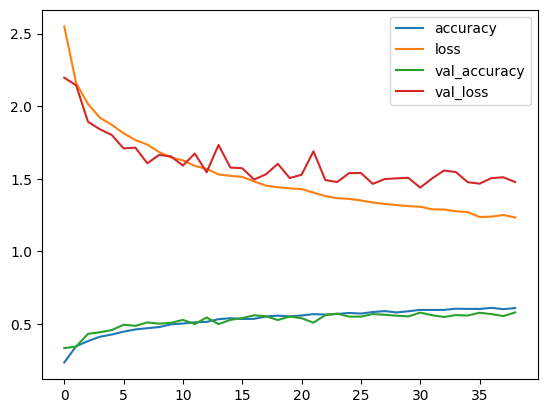

In [28]:
pd.DataFrame(history_model_1.history).plot()

#### Results